In [295]:
import numpy as np
import room_acoustics_utils as utils
import pyroomacoustics as pra
import random

In [296]:
room_dim = np.array([0.5, 0.5, 0.5])
head_pos = 0.5*room_dim


In [297]:
head_yaw = 0.25*np.pi
# head_yaw = 0

In [ ]:
# def random_mouth_position(head_pos, head_yaw):
#     hpx, hpy, hpz = head_pos
#     rdx = random.uniform(-0.01, 0.01)
#     rdy = random.uniform(0.11, 0.15)
#     rdz = random.uniform(-0.04, -0.02)
#     x = hpx + rdx*np.cos(head_yaw) - rdy*np.sin(head_yaw)
#     y = hpy + rdx*np.sin(head_yaw) + rdy*np.cos(head_yaw)
#     z = hpz + rdz
#     return np.array([x, y, z])

def random_mouth_position(head_pos, head_yaw, head_pitch):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(-0.01, 0.01)
    rdy = random.uniform(0.11, 0.15)
    rdz = random.uniform(-0.04, -0.02)
    x = hpx + rdx*np.cos(head_yaw) - rdy*np.sin(head_yaw)
    y = hpy + rdx*np.sin(head_yaw) + rdy*np.cos(head_yaw)
    z = hpz + rdz*np.cos(head_pitch)
    return np.array([x, y, z])
    # mic_l_u = np.array([
    # lex + mic_dist*np.sin(head_pitch)*np.sin(head_yaw), 
    # ley - mic_dist*np.sin(head_pitch)*np.cos(head_yaw), 
    # lez + mic_dist*np.cos(head_pitch)])


In [299]:
def random_ears_position(head_pos, head_yaw):
    hpx, hpy, hpz = head_pos
    rdx = 0.08
    ear_center_l = np.array([hpx - rdx*np.cos(head_yaw), hpy - rdx*np.sin(head_yaw), hpz])
    ear_center_r = np.array([hpx + rdx*np.cos(head_yaw), hpy + rdx*np.sin(head_yaw), hpz])
    return np.array([ear_center_l, ear_center_r])

In [300]:
ears_pos = random_ears_position(head_pos, head_yaw=head_yaw)
mouth_pos = random_mouth_position(head_pos, head_yaw=head_yaw)

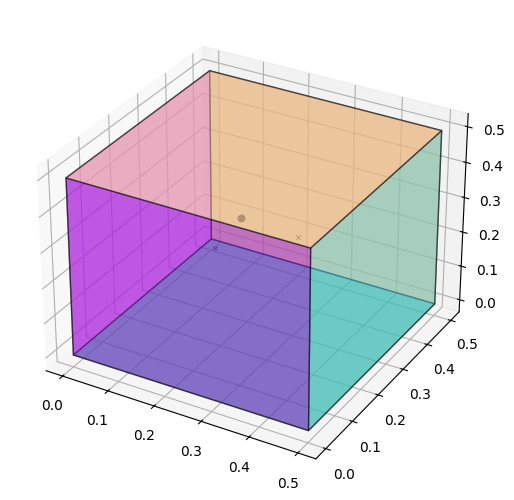

In [301]:
# Create room and add necessary sources.
room = pra.ShoeBox(room_dim)
room.add_source(mouth_pos)
room.add_microphone(ears_pos[0])
room.add_microphone(ears_pos[1])
room.plot();

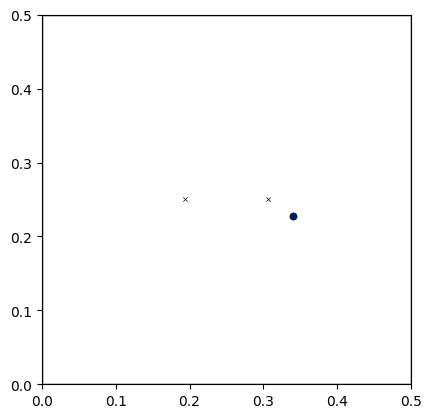

In [302]:
# SIDE VIEW
room = pra.ShoeBox(room_dim[1:])
room.add_source(mouth_pos[1:])
room.add_microphone(ears_pos[0][1:])
room.add_microphone(ears_pos[1][1:])
room.plot();

In [303]:
# def define_mics_position(ears_pos, head_pitch, mic_dist=0.1):
#     ear_center_l, ear_center_r = ears_pos
#     lex, ley, lez = ear_center_l
#     rex, rey, rez = ear_center_r
#     # Left mic, above left ear.
#     mic_l_u = np.array([lex, ley - mic_dist*np.sin(head_pitch), lez + mic_dist*np.cos(head_pitch)])
#     # Left mic, below left ear.
#     mic_l_d = np.array([lex, ley + mic_dist*np.sin(head_pitch), lez - mic_dist*np.cos(head_pitch)])
#     # Right mic, above right ear.
#     mic_r_u = np.array([rex, rey - mic_dist*np.sin(head_pitch), rez + mic_dist*np.cos(head_pitch)])
#     # Right mic, below right ear.
#     mic_r_d = np.array([rex, rey + mic_dist*np.sin(head_pitch), rez - mic_dist*np.cos(head_pitch)])

#     return np.array([mic_l_u, mic_l_d, mic_r_u, mic_r_d])

    # ear_center_l = np.array([hpx - rdx*np.cos(head_yaw), hpy - rdx*np.sin(head_yaw), hpz])
    # ear_center_r = np.array([hpx + rdx*np.cos(head_yaw), hpy + rdx*np.sin(head_yaw), hpz])

def define_mics_position(ears_pos, head_yaw, head_pitch, mic_dist=0.1):
    ear_center_l, ear_center_r = ears_pos
    lex, ley, lez = ear_center_l
    rex, rey, rez = ear_center_r
    # Left mic, above left ear.
    mic_l_u = np.array([lex + mic_dist*np.sin(head_pitch)*np.sin(head_yaw), ley - mic_dist*np.sin(head_pitch)*np.cos(head_yaw), lez + mic_dist*np.cos(head_pitch)])
    # Left mic, below left er.
    mic_l_d = np.array([lex - mic_dist*np.sin(head_pitch)*np.sin(head_yaw), ley + mic_dist*np.sin(head_pitch)*np.cos(head_yaw), lez - mic_dist*np.cos(head_pitch)])
    # Right mic, above right ear.
    mic_r_u = np.array([rex + mic_dist*np.sin(head_pitch)*np.sin(head_yaw), rey - mic_dist*np.sin(head_pitch)*np.cos(head_yaw), rez + mic_dist*np.cos(head_pitch)])
    # Right mic, below right ear.
    mic_r_d = np.array([rex - mic_dist*np.sin(head_pitch)*np.sin(head_yaw), rey + mic_dist*np.sin(head_pitch)*np.cos(head_yaw), rez - mic_dist*np.cos(head_pitch)])

    return np.array([mic_l_u, mic_l_d, mic_r_u, mic_r_d])

In [311]:
mics_pos = define_mics_position(ears_pos, head_yaw=head_yaw, head_pitch=0.25*np.pi, mic_dist=0.1)
mics_pos = mics_pos

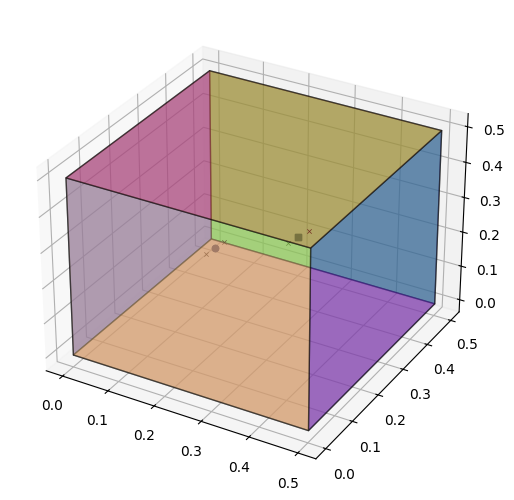

In [312]:
# Create room and add necessary sources.
room = pra.ShoeBox(room_dim)
room.add_source(ears_pos[0])
room.add_source(ears_pos[1])
# Simulate acoustic scene.
room.add_microphone_array(mics_pos.T)
# room.add_microphone_array(define_mics_position(ears_pos, head_yaw=0, head_pitch=0, mic_dist=0.1).T)

room.plot();

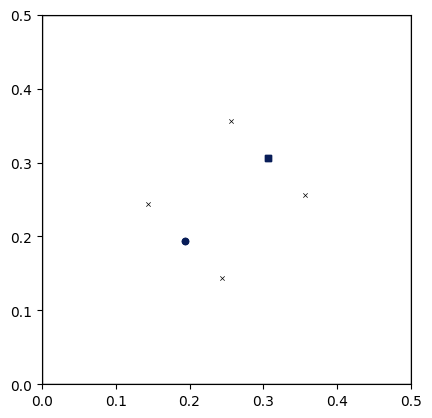

In [316]:
# VU DU HAUT
room = pra.ShoeBox(room_dim[:2])
room.add_source(ears_pos[0][:2])
room.add_source(ears_pos[1][:2])
room.add_microphone_array(mics_pos.T[:2])
room.plot();

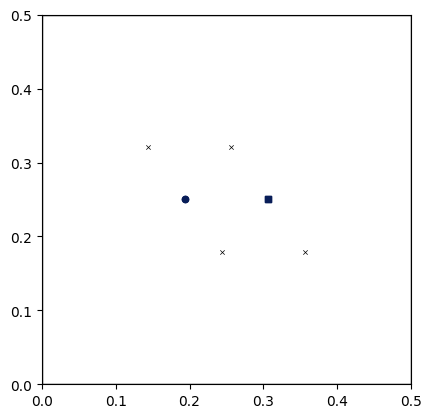

In [317]:
# SIDE VIEW (ECRAN Y)
room = pra.ShoeBox(room_dim[1:])
room.add_source(ears_pos[0][1:])
room.add_source(ears_pos[1][1:])# Simulate acoustic scene.
room.add_microphone_array(mics_pos.T[1:])
room.plot();

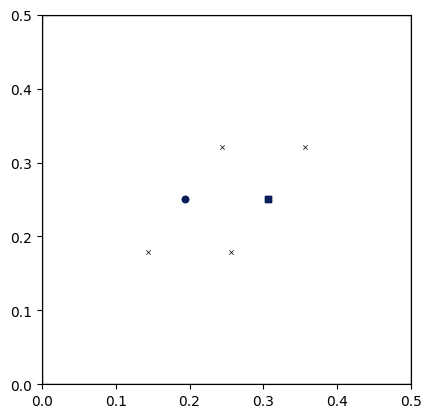

In [318]:
# OTHER SIDE VIEW (ECRAN X)
room = pra.ShoeBox(room_dim[0::2])
room.add_source(ears_pos[0][0::2])
room.add_source(ears_pos[1][0::2])# Simulate acoustic scene.
room.add_microphone_array(mics_pos.T[0::2])
room.plot();

In [39]:
head_pitch = 0.25*np.pi

In [ ]:
def define_mics_position(ears_pos, head_yaw, head_pitch, mic_dist=0.1):
    ear_center_l, ear_center_r = ears_pos
    lex, ley, lez = ear_center_l
    rex, rey, rez = ear_center_r
    # Left mic, above left ear.
    mic_l_u = np.array([lex, ley - mic_dist*np.sin(head_pitch), lez - mic_dist*np.cos(head_pitch)])
    # Left mic, below left ear.
    mic_l_d = np.array([lex, ley + mic_dist*np.sin(head_pitch), lez - mic_dist*np.cos(head_pitch)])
    # Right mic, above right ear.
    mic_r_u = np.array([rex, rey - mic_dist*np.sin(head_pitch), rez - mic_dist*np.cos(head_pitch)])
    # Right mic, below right ear.
    mic_r_d = np.array([rex, rey + mic_dist*np.sin(head_pitch), rez - mic_dist*np.cos(head_pitch)])
                                
    mic_l_u = np.array([lex, ley, lez - 0.2])
    mic_l_d = np.array([lex, ley, lez + 0.2])    
    mic_r_u = np.array([rex, rey, rez - 0.2])
    mic_r_d = np.array([rex, rey, rez + 0.2])

    return np.array([mic_l_u, mic_l_d, mic_r_u, mic_r_d])

In [12]:
room_dim = utils.random_room_dimensions()
head_pos = utils.random_head_position(room_dim)
head_ang = utils.random_head_angle()
ears_pos = utils.random_ears_position(head_pos, head_ang)
mics_pos = utils.define_mics_position(ears_pos)
mouth_pos = utils.random_mouth_position(head_pos,  head_ang)
distr_pos = utils.random_distractor_position(room_dim, head_pos)
distr_snr = utils.random_snr(-15, 0)
noise_snr = utils.random_snr(-30, 0)

In [4]:
head_pos

array([3.07705063, 1.8011154 , 1.23800925])

In [79]:
dmnd_path = '/home/ovistetom/Documents/Python_Local/pyroom/database/DMND/ch01_0000.flac'
lisp_path = '/home/ovistetom/Documents/Python_Local/pyroom/database/LISP/19-198-0001.flac'
vctk_path = '/home/ovistetom/Documents/Python_Local/pyroom/database/VCTK/p225_192_mic2.flac'

In [80]:
dmnd_signal, sr = torchaudio.load(dmnd_path)
lisp_signal, sr = torchaudio.load(lisp_path)
vctk_signal, sr = torchaudio.load(vctk_path)

In [81]:
dmnd_signal.abs().max()

tensor(1.0000)

In [82]:
# Normalize to 0.5.
dmnd_signal /= 2*dmnd_signal.abs().max()
lisp_signal /= 2*lisp_signal.abs().max()
vctk_signal /= 2*vctk_signal.abs().max()

In [83]:
# Save
torchaudio.save(dmnd_path, src=dmnd_signal, sample_rate=sr)
torchaudio.save(lisp_path, src=lisp_signal, sample_rate=sr)
torchaudio.save(vctk_path, src=vctk_signal, sample_rate=sr)